In [ ]:
# Installing the libraries with the specified version
#   !pip install --no-deps --force-reinstall tensorflow==2.16.2 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [4]:
# Leer todos los archivos CSV dentro del directorio "pos"
current_dir = Path.cwd()
pos_dir = current_dir / "pos"

print("Current dir:", current_dir)
print("POS dir:", pos_dir)

if not pos_dir.exists() or not pos_dir.is_dir():
    raise FileNotFoundError(f"No existe el directorio: {pos_dir}")

csv_files = sorted(pos_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No se encontraron archivos .csv en: {pos_dir}")

df_pos = []
for file_path in csv_files:
    print(f"Leyendo: {file_path.name}")
    df = pd.read_csv(file_path)
    df["source_file"] = file_path.name
    df_pos.append(df)

df_pos = pd.concat(df_pos, ignore_index=True)
print(f"Total archivos leídos: {len(csv_files)}")
print(f"Total filas consolidadas: {len(df_pos)}")
df_pos.head()

Current dir: /Users/cesarpasillas/Gladis_phd/fleet_analysis/data
POS dir: /Users/cesarpasillas/Gladis_phd/fleet_analysis/data/pos
Leyendo: pos20240101_20240201_000000000000.csv
Leyendo: pos20240101_20240201_000000000001.csv
Leyendo: pos20240101_20240201_000000000002.csv
Leyendo: pos20240101_20240201_000000000003.csv
Leyendo: pos20240101_20240201_000000000004.csv
Leyendo: pos20240101_20240201_000000000005.csv
Leyendo: pos20240101_20240201_000000000006.csv
Leyendo: pos20240101_20240201_000000000007.csv
Leyendo: pos20240101_20240201_000000000008.csv
Leyendo: pos20240101_20240201_000000000009.csv
Leyendo: pos20240101_20240201_000000000010.csv
Total archivos leídos: 11
Total filas consolidadas: 5916769


,assetId,clientId,latitude,longitude,olc,gpsTimestamp,serverTimestamp,satellites,avrgFuelEconomy,instFuelEconomy,totalFuelHiRes,totalFuel,gpsDistance,eventType,source_file
0,97280,1392,18.194336,-95.594832,76C65CV4+P3M,1.705723e+12,1705722696854,6.0,NaN,NaN,NaN,NaN,100194.1,512,pos20240101_20240201_000000000000.csv
1,97280,1392,18.685375,-96.330444,76C5MMP9+5R3,1.705729e+12,1705729467413,15.0,NaN,NaN,NaN,NaN,100286.3,512,pos20240101_20240201_000000000000.csv
2,91649,300,18.087474,-94.133892,76C73VP8+XCQ,1.705475e+12,1705475147920,15.0,NaN,NaN,NaN,NaN,104223.2,512,pos20240101_20240201_000000000000.csv
3,91649,300,18.047959,-94.345863,76C72MX3+5MJ,1.705193e+12,1705193290884,13.0,NaN,NaN,NaN,NaN,103631.4,512,pos20240101_20240201_000000000000.csv
4,101123,1467,18.612115,-90.789785,76CFJ666+R3W,1.705491e+12,1705490643987,11.0,NaN,NaN,NaN,NaN,113883.2,512,pos20240101_20240201_000000000000.csv


In [5]:
df_pos.shape

(5916769, 15)

In [6]:
# Eliminar columnas de consumo de combustible en df_pos (sin importar mayúsculas/minúsculas)
cols_to_remove = {"AVRGFUELECONOMY", "INSTFUELECONOMY", "TOTALFUEL", "TOTALFUELHIRES", "SOURCE_FILE"}

df_pos = df_pos.drop(
    columns=[c for c in df_pos.columns if c.upper() in cols_to_remove],
    errors="ignore"
)

print("Columnas actuales:", df_pos.columns.tolist())

Columnas actuales: ['assetId', 'clientId', 'latitude', 'longitude', 'olc', 'gpsTimestamp', 'serverTimestamp', 'satellites', 'gpsDistance', 'eventType']


In [5]:
#df_pos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5916769 entries, 0 to 5916768
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   assetId          int64  
 1   clientId         int64  
 2   latitude         float64
 3   longitude        float64
 4   olc              object 
 5   gpsTimestamp     float64
 6   serverTimestamp  int64  
 7   satellites       float64
 8   gpsDistance      float64
 9   eventType        int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 451.4+ MB


In [6]:
#df_pos.isnull()

,assetId,clientId,latitude,longitude,olc,gpsTimestamp,serverTimestamp,satellites,gpsDistance,eventType
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
5916764,False,False,False,False,False,False,False,False,False,False
5916765,False,False,False,False,False,False,False,False,False,False
5916766,False,False,False,False,False,False,False,False,False,False
5916767,False,False,False,False,False,False,False,False,False,False


In [7]:
# Leer EventType.csv (buscando en rutas comunes) y unirlo con df_pos por eventType
eventtype_candidates = [
    current_dir / "EventType.csv",
    pos_dir / "EventType.csv",
    Path.cwd() / "EventType.csv",
]

eventtype_path = next((p for p in eventtype_candidates if p.exists()), None)
if eventtype_path is None:
    raise FileNotFoundError("No se encontró EventType.csv en current_dir, pos_dir o Path.cwd().")

df_eventtype = pd.read_csv(eventtype_path)
df_eventtype.columns = [c.strip() for c in df_eventtype.columns]

In [8]:
#df_eventtype

,eventType,conteo
0,201,59
1,202,32
2,301,47
3,302,2
4,303,12
...,...,...
142,744,2
143,745,1
144,746,2
145,901,36702


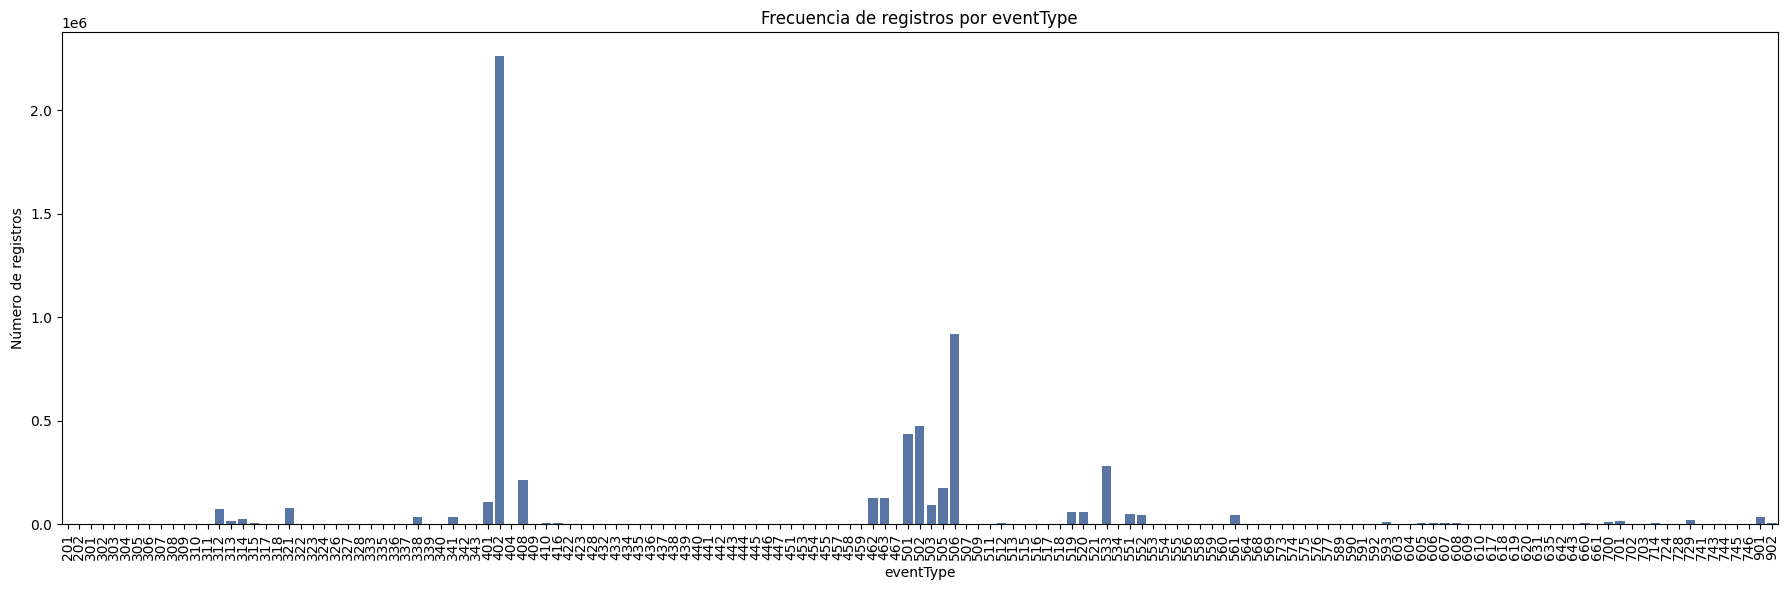

In [8]:
# Visualizar todos los eventType presentes en df_pos
event_counts = (
    df_pos.groupby("eventType", dropna=False)
    .size()
    .reset_index(name="conteo")
    .sort_values("eventType")
)

# Agregar etiqueta del evento si ya existe en df_pos (después del merge)
if "Key" in df_pos.columns:
    labels = df_pos[["eventType", "Key"]].dropna().drop_duplicates()
    event_counts = event_counts.merge(labels, on="eventType", how="left")

display(event_counts)

# Gráfica 1: frecuencia por eventType (numérico)
plt.figure(figsize=(18, 6))
sns.barplot(data=event_counts, x="eventType", y="conteo", color="#4C72B0")
plt.title("Frecuencia de registros por eventType")
plt.xlabel("eventType")
plt.ylabel("Número de registros")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Gráfica 2: todos los eventType con su Key (si está disponible), ordenado por frecuencia
if "Key" in event_counts.columns:
    plot_df = event_counts.sort_values("conteo", ascending=False).copy()
    plot_df["label"] = plot_df["eventType"].astype(str) + " - " + plot_df["Key"].fillna("Sin etiqueta")

    plt.figure(figsize=(12, max(8, len(plot_df) * 0.25)))
    sns.barplot(data=plot_df, y="label", x="conteo", color="#55A868")
    plt.title("Todos los eventType ordenados por frecuencia")
    plt.xlabel("Número de registros")
    plt.ylabel("eventType - Key")
    plt.tight_layout()
    plt.show()

In [9]:
# Detectar columna llave en EventType.csv
possible_keys = ["eventType", "Event_Type", "event_type", "eventtype", "id", "Id", "ID"]
key_col = next((c for c in possible_keys if c in df_eventtype.columns), None)
if key_col is None:
    raise KeyError(f"No se encontró columna llave de tipo evento en EventType.csv. Columnas: {df_eventtype.columns.tolist()}")

if key_col != "eventType":
    df_eventtype = df_eventtype.rename(columns={key_col: "eventType"})

In [10]:
# Asegurar tipo numérico para merge
df_pos["eventType"] = pd.to_numeric(df_pos["eventType"], errors="coerce")
df_eventtype["eventType"] = pd.to_numeric(df_eventtype["eventType"], errors="coerce")

# Opcional: eliminar duplicados de catálogos por eventType
df_eventtype = df_eventtype.drop_duplicates(subset=["eventType"])

# Unir
df_pos = df_pos.merge(df_eventtype, on="eventType", how="left", validate="many_to_one")

# Ordenar datos por eventType
df_pos = df_pos.sort_values(by="eventType", ascending=True, na_position="last").reset_index(drop=True)

print(f"Archivo leído: {eventtype_path}")
print(f"Filas df_pos después del merge: {len(df_pos):,}")
print(f"eventType sin match: {df_pos[df_pos.filter(items=df_eventtype.columns.difference(['eventType'])).columns[0]].isna().sum() if len(df_eventtype.columns) > 1 else 0:,}")
df_pos.head()

Archivo leído: /Users/cesarpasillas/Gladis_phd/fleet_analysis/data/EventType.csv
Filas df_pos después del merge: 5,916,769
eventType sin match: 13,912


,assetId,clientId,latitude,longitude,olc,gpsTimestamp,serverTimestamp,satellites,gpsDistance,eventType,Key,Description
0,138022,2956,21.481911,-102.234802,75HVFQJ8+Q38,1.704485e+12,1704484570582,20.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
1,91694,1109,20.435488,-103.538811,75GRCFP6+5FW,1.705587e+12,1705611564277,20.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
2,138022,2956,22.835272,-102.534554,75JVRFP8+454,1.704270e+12,1704270242066,17.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
3,126243,455,21.199076,-102.339119,75HV5MX6+J9J,1.705463e+12,1705463474221,19.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
4,134833,586,22.906576,-98.562378,76J3WC4Q+J2Q,1.706689e+12,1706689286027,13.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.


In [11]:
# Filtrar todos los registros con eventType = 201
df_eventtype_201 = df_pos[df_pos["eventType"] == 201].copy()

print(f"Total de registros con eventType 201: {len(df_eventtype_201):,}")
df_eventtype_201

Total de registros con eventType 201: 59


,assetId,clientId,latitude,longitude,olc,gpsTimestamp,serverTimestamp,satellites,gpsDistance,eventType,Key,Description
0,138022,2956,21.481911,-102.234802,75HVFQJ8+Q38,1.704485e+12,1704484570582,20.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
1,91694,1109,20.435488,-103.538811,75GRCFP6+5FW,1.705587e+12,1705611564277,20.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
2,138022,2956,22.835272,-102.534554,75JVRFP8+454,1.704270e+12,1704270242066,17.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
3,126243,455,21.199076,-102.339119,75HV5MX6+J9J,1.705463e+12,1705463474221,19.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
4,134833,586,22.906576,-98.562378,76J3WC4Q+J2Q,1.706689e+12,1706689286027,13.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
5,135594,1730,18.606152,-96.213013,76C5JQ4P+FQ9,1.706745e+12,1706744821114,15.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
6,55620,1467,18.831448,-96.722038,76C5R7JH+H5G,1.705196e+12,1705195607409,19.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
7,138022,2956,21.172577,-101.870155,75HW54FH+2WQ,1.706556e+12,1706555656814,18.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
8,126243,455,22.850983,-102.609673,75JVV92R+94W,1.705234e+12,1705234067805,20.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.
9,126243,455,21.081577,-104.663872,75HQ38JP+JFJ,1.706156e+12,1706155793484,20.0,0.0,201,SOS / PANIC_BUTTON,El botón físico de emergencia fue presionado.


In [12]:
# Convertir gpsTimestamp y serverTimestamp a fecha/hora legible (sin reemplazar columnas originales)
def to_readable_datetime(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    sample = s.dropna()

    if sample.empty:
        return pd.to_datetime(s, errors="coerce", utc=True)

    median_val = sample.abs().median()
    if median_val >= 1e17:
        unit = "ns"
    elif median_val >= 1e14:
        unit = "us"
    elif median_val >= 1e11:
        unit = "ms"
    else:
        unit = "s"

    return pd.to_datetime(s, unit=unit, errors="coerce", utc=True)

if "gpsTimestamp" in df_pos.columns:
    df_pos["gpsTimestamp_readable"] = to_readable_datetime(df_pos["gpsTimestamp"])
    print("gpsTimestamp -> gpsTimestamp_readable")
else:
    print("Columna no encontrada: gpsTimestamp")

if "serverTimestamp" in df_pos.columns:
    df_pos["serverTimestamp_readable"] = to_readable_datetime(df_pos["serverTimestamp"])
    print("serverTimestamp -> serverTimestamp_readable")
else:
    print("Columna no encontrada: serverTimestamp")

cols_preview = [
    c for c in [
        "gpsTimestamp", "gpsTimestamp_readable",
        "serverTimestamp", "serverTimestamp_readable"
    ] if c in df_pos.columns
]

display(df_pos[cols_preview].head())

gpsTimestamp -> gpsTimestamp_readable
serverTimestamp -> serverTimestamp_readable


,gpsTimestamp,gpsTimestamp_readable,serverTimestamp,serverTimestamp_readable
0,1.704485e+12,2024-01-05 19:56:05+00:00,1704484570582,2024-01-05 19:56:10.582000+00:00
1,1.705587e+12,2024-01-18 14:11:11+00:00,1705611564277,2024-01-18 20:59:24.277000+00:00
2,1.704270e+12,2024-01-03 08:23:47+00:00,1704270242066,2024-01-03 08:24:02.066000+00:00
3,1.705463e+12,2024-01-17 03:51:09+00:00,1705463474221,2024-01-17 03:51:14.221000+00:00
4,1.706689e+12,2024-01-31 08:21:22+00:00,1706689286027,2024-01-31 08:21:26.027000+00:00


In [13]:
# 1) Registros con eventType NaN (si existen)
df_eventtype_nan = df_pos[df_pos["eventType"].isna()].copy()
print(f"Registros con eventType NaN: {len(df_eventtype_nan):,}")
display(df_eventtype_nan.head())

# 2) Eventos faltantes en catálogo (eventType sí existe, pero sin Key/Description)
df_eventos_faltantes = df_pos[df_pos["Key"].isna()].copy()
print(f"Registros con eventType sin correspondencia en catálogo (Key NaN): {len(df_eventos_faltantes):,}")

resumen_faltantes = (
    df_eventos_faltantes.groupby("eventType", dropna=False)
    .size()
    .reset_index(name="conteo")
    .sort_values("conteo", ascending=False)
)

display(resumen_faltantes)

Registros con eventType NaN: 0


,assetId,clientId,latitude,longitude,olc,gpsTimestamp,serverTimestamp,satellites,gpsDistance,eventType,Key,Description,gpsTimestamp_readable,serverTimestamp_readable


Registros con eventType sin correspondencia en catálogo (Key NaN): 0


,eventType,conteo


In [14]:
# Agrupar todos los eventos únicos con su información completa
eventos_completos = (
    df_pos.groupby("eventType", dropna=False)
    .agg({
        "Key": "first",
        "Description": "first",
        "assetId": "count"
    })
    .rename(columns={"assetId": "total_registros"})
    .reset_index()
)

# Filtrar SOLO los que tienen Key en NaN (sin catálogo) y ordenar por eventType
eventos_key_nan = (
    eventos_completos[eventos_completos["Key"].isna()]
    .sort_values("eventType", ascending=True, na_position="last")
    .reset_index(drop=True)
)

print(f"Total de eventType únicos: {len(eventos_completos)}")
print(f"Eventos con Key NaN: {len(eventos_key_nan)}")
print(f"\nTotal de registros (Key NaN): {eventos_key_nan['total_registros'].sum():,}")

display(eventos_key_nan)

Total de eventType únicos: 147
Eventos con Key NaN: 0

Total de registros (Key NaN): 0


,eventType,Key,Description,total_registros


In [15]:
# Reordenar columnas (sin perder ninguna)
columnas_prioridad = [
    "assetId", "clientId", "Key", "eventType",
    "gpsTimestamp", "gpsTimestamp_readable",
    "serverTimestamp", "serverTimestamp_readable",
     "Description"
]

# Tomar solo las columnas de prioridad que realmente existan
columnas_existentes = [c for c in columnas_prioridad if c in df_pos.columns]

# Agregar el resto de columnas al final, conservando orden original
columnas_restantes = [c for c in df_pos.columns if c not in columnas_existentes]

# Nuevo orden final
nuevo_orden = columnas_existentes + columnas_restantes
df_pos = df_pos[nuevo_orden]

print("Columnas reordenadas correctamente")
print(df_pos.columns.tolist())
df_pos.head(10)

Columnas reordenadas correctamente
['assetId', 'clientId', 'Key', 'eventType', 'gpsTimestamp', 'gpsTimestamp_readable', 'serverTimestamp', 'serverTimestamp_readable', 'Description', 'latitude', 'longitude', 'olc', 'satellites', 'gpsDistance']


,assetId,clientId,Key,eventType,gpsTimestamp,gpsTimestamp_readable,serverTimestamp,serverTimestamp_readable,Description,latitude,longitude,olc,satellites,gpsDistance
0,138022,2956,SOS / PANIC_BUTTON,201,1.704485e+12,2024-01-05 19:56:05+00:00,1704484570582,2024-01-05 19:56:10.582000+00:00,El botón físico de emergencia fue presionado.,21.481911,-102.234802,75HVFQJ8+Q38,20.0,0.0
1,91694,1109,SOS / PANIC_BUTTON,201,1.705587e+12,2024-01-18 14:11:11+00:00,1705611564277,2024-01-18 20:59:24.277000+00:00,El botón físico de emergencia fue presionado.,20.435488,-103.538811,75GRCFP6+5FW,20.0,0.0
2,138022,2956,SOS / PANIC_BUTTON,201,1.704270e+12,2024-01-03 08:23:47+00:00,1704270242066,2024-01-03 08:24:02.066000+00:00,El botón físico de emergencia fue presionado.,22.835272,-102.534554,75JVRFP8+454,17.0,0.0
3,126243,455,SOS / PANIC_BUTTON,201,1.705463e+12,2024-01-17 03:51:09+00:00,1705463474221,2024-01-17 03:51:14.221000+00:00,El botón físico de emergencia fue presionado.,21.199076,-102.339119,75HV5MX6+J9J,19.0,0.0
4,134833,586,SOS / PANIC_BUTTON,201,1.706689e+12,2024-01-31 08:21:22+00:00,1706689286027,2024-01-31 08:21:26.027000+00:00,El botón físico de emergencia fue presionado.,22.906576,-98.562378,76J3WC4Q+J2Q,13.0,0.0
5,135594,1730,SOS / PANIC_BUTTON,201,1.706745e+12,2024-01-31 23:46:51+00:00,1706744821114,2024-01-31 23:47:01.114000+00:00,El botón físico de emergencia fue presionado.,18.606152,-96.213013,76C5JQ4P+FQ9,15.0,0.0
6,55620,1467,SOS / PANIC_BUTTON,201,1.705196e+12,2024-01-14 01:26:45+00:00,1705195607409,2024-01-14 01:26:47.409000+00:00,El botón físico de emergencia fue presionado.,18.831448,-96.722038,76C5R7JH+H5G,19.0,0.0
7,138022,2956,SOS / PANIC_BUTTON,201,1.706556e+12,2024-01-29 19:14:13+00:00,1706555656814,2024-01-29 19:14:16.814000+00:00,El botón físico de emergencia fue presionado.,21.172577,-101.870155,75HW54FH+2WQ,18.0,0.0
8,126243,455,SOS / PANIC_BUTTON,201,1.705234e+12,2024-01-14 12:07:46+00:00,1705234067805,2024-01-14 12:07:47.805000+00:00,El botón físico de emergencia fue presionado.,22.850983,-102.609673,75JVV92R+94W,20.0,0.0
9,126243,455,SOS / PANIC_BUTTON,201,1.706156e+12,2024-01-25 04:09:06+00:00,1706155793484,2024-01-25 04:09:53.484000+00:00,El botón físico de emergencia fue presionado.,21.081577,-104.663872,75HQ38JP+JFJ,20.0,0.0


In [16]:
import folium

# Si no tienes folium, ejecuta en otra celda:
# !pip install folium -q

# Cambia estos valores por el Truck (assetId) y cliente (clientId) que quieras ver
asset_id_objetivo = 598
client_id_objetivo = 64

ruta = df_pos[
    (df_pos["assetId"] == asset_id_objetivo) &
    (df_pos["clientId"] == client_id_objetivo)
] .copy()

# Quitar puntos sin coordenadas
ruta = ruta.dropna(subset=["latitude", "longitude"])

if ruta.empty:
    raise ValueError("No hay datos para ese assetId/clientId o faltan coordenadas.")

# Orden temporal
if "gpsTimestamp_readable" in ruta.columns:
    ruta = ruta.sort_values("gpsTimestamp_readable")
elif "gpsTimestamp" in ruta.columns:
    ruta = ruta.sort_values("gpsTimestamp")

coords = ruta[["latitude", "longitude"]].to_numpy().tolist()
total_puntos = len(coords)

# Reducir puntos para evitar que el HTML del mapa sea demasiado pesado en notebook
max_points = 3000
if total_puntos > max_points:
    step = max(1, total_puntos // max_points)
    coords = coords[::step]
    print(f"Se redujeron puntos de {total_puntos:,} a {len(coords):,} para visualización.")
else:
    print(f"Total de puntos en la ruta: {total_puntos:,}")

# Crear mapa centrado en el primer punto
m = folium.Map(location=coords[0], zoom_start=12, tiles="OpenStreetMap")

# Dibujar ruta
folium.PolyLine(
    coords,
    color="blue",
    weight=4,
    opacity=0.8,
    tooltip=f"Ruta assetId={asset_id_objetivo}, clientId={client_id_objetivo}"
).add_to(m)

# Marcadores inicio/fin
inicio = ruta.iloc[0]
fin = ruta.iloc[-1]

folium.Marker(
    [inicio["latitude"], inicio["longitude"]],
    popup=f"Inicio\nassetId={asset_id_objetivo}\nclientId={client_id_objetivo}",
    icon=folium.Icon(color="green", icon="play")
).add_to(m)

folium.Marker(
    [fin["latitude"], fin["longitude"]],
    popup=f"Fin\nassetId={asset_id_objetivo}\nclientId={client_id_objetivo}",
    icon=folium.Icon(color="red", icon="stop")
).add_to(m)

# Guardar también en archivo para abrir en navegador si el render del notebook falla
output_html = f"ruta_asset_{asset_id_objetivo}_client_{client_id_objetivo}.html"
m.save(output_html)
print(f"Mapa guardado en: {output_html}")

m

Total de puntos en la ruta: 202
Mapa guardado en: ruta_asset_598_client_64.html


In [17]:
# Filtrar rutas para assetId=598 y clientId=64

# Asegurar que exista df_rutas
if 'df_rutas' not in globals():
    if 'rutas_analisis' in globals() and len(rutas_analisis) > 0:
        df_rutas = pd.DataFrame(rutas_analisis)
        print(f"df_rutas creado desde rutas_analisis con {len(df_rutas):,} filas")
    else:
        raise NameError("No existe df_rutas ni rutas_analisis con datos. Ejecuta primero la celda que construye las rutas.")

required_cols = [
    'assetId', 'clientId', 'inicio_timestamp', 'fin_timestamp',
    'duracion_horas', 'distancia_recorrida', 'total_eventos', 'tipos_eventos_unicos'
]
missing_cols = [c for c in required_cols if c not in df_rutas.columns]
if missing_cols:
    raise KeyError(f"Faltan columnas en df_rutas: {missing_cols}")

rutas_598_64 = df_rutas[
    (df_rutas['assetId'] == 598) &
    (df_rutas['clientId'] == 64)
].copy()

# Ordenar por fecha de inicio
rutas_598_64 = rutas_598_64.sort_values('inicio_timestamp').reset_index(drop=True)

# Crear tabla con información de rutas
tabla_rutas = rutas_598_64[[
    'inicio_timestamp', 'fin_timestamp', 'duracion_horas',
    'distancia_recorrida', 'total_eventos', 'tipos_eventos_unicos'
]].copy()

tabla_rutas.columns = [
    'Inicio Ruta', 'Fin Ruta', 'Duración (horas)',
    'Distancia (km)', 'Total Eventos', 'Tipos Eventos'
]

print(f"Total de rutas encontradas para assetId=598, clientId=64: {len(rutas_598_64)}")
print(f"\n{'='*100}")
display(tabla_rutas)

# Resumen de estadísticas
print(f"\n{'='*100}")
print("ESTADÍSTICAS DE RUTAS:")
print(f"- Duración promedio: {rutas_598_64['duracion_horas'].mean():.2f} horas")
print(f"- Distancia total recorrida: {rutas_598_64['distancia_recorrida'].sum():.2f} km")
print(f"- Total de eventos en todas las rutas: {rutas_598_64['total_eventos'].sum():,}")
print(f"- Eventos promedio por ruta: {rutas_598_64['total_eventos'].mean():.0f}")

NameError: No existe df_rutas ni rutas_analisis con datos. Ejecuta primero la celda que construye las rutas.

In [18]:
# Filtrar registros de la ruta 1 (índice 1 en rutas_598_64)
ruta_1 = rutas_598_64.iloc[1]

# Filtrar todos los registros de df_pos que corresponden a esta ruta
registros_ruta_1 = df_pos[
    (df_pos['assetId'] == ruta_1['assetId']) &
    (df_pos['clientId'] == ruta_1['clientId']) &
    (df_pos['gpsTimestamp_readable'] >= ruta_1['inicio_timestamp']) &
    (df_pos['gpsTimestamp_readable'] <= ruta_1['fin_timestamp'])
].copy()

# Ordenar por timestamp
registros_ruta_1 = registros_ruta_1.sort_values('gpsTimestamp_readable').reset_index(drop=True)

print(f"Registros de la Ruta 1:")
print(f"Inicio: {ruta_1['inicio_timestamp']}")
print(f"Fin: {ruta_1['fin_timestamp']}")
print(f"Total de registros: {len(registros_ruta_1)}")
print(f"\n{'='*100}")

display(registros_ruta_1)

NameError: name 'rutas_598_64' is not defined

In [19]:
# Filtrar registros con eventType 519 o 520, ordenados por assetId y clientId
registros_519_520 = df_pos[df_pos["eventType"].isin([519, 520])].copy()

# Ordenar por assetId y clientId
registros_519_520 = registros_519_520.sort_values(
    by=["assetId", "clientId", "gpsTimestamp_readable"],
    ascending=True,
    na_position="last"
).reset_index(drop=True)

print(f"Total de registros con eventType 519 o 520: {len(registros_519_520):,}")
print(f"Registros únicos por (assetId, clientId): {registros_519_520.groupby(['assetId', 'clientId']).size().shape[0]}")

display(registros_519_520)

Total de registros con eventType 519 o 520: 118,604
Registros únicos por (assetId, clientId): 29039


,assetId,clientId,Key,eventType,gpsTimestamp,gpsTimestamp_readable,serverTimestamp,serverTimestamp_readable,Description,latitude,longitude,olc,satellites,gpsDistance
0,598,64,IGNITION_ON,519,1.705235e+12,2024-01-14 12:15:15+00:00,1705234510845,2024-01-14 12:15:10.845000+00:00,Reporte generado al detectarse que se enciende...,30.555136,-111.139575,852CHV46+353,12.0,468479.781
1,598,64,IGNITION_ON,519,1.706628e+12,2024-01-30 15:20:31+00:00,1706628025504,2024-01-30 15:20:25.504000+00:00,Reporte generado al detectarse que se enciende...,31.863500,-112.846255,8539V573+CF5,10.0,472845.409
2,598,64,IGNITION_ON,519,1.706631e+12,2024-01-30 16:03:50+00:00,1706630623576,2024-01-30 16:03:43.576000+00:00,Reporte generado al detectarse que se enciende...,31.863499,-112.846227,8539V573+9GR,10.0,472845.418
3,598,64,IGNITION_ON,519,1.706741e+12,2024-01-31 22:39:27+00:00,1706740770832,2024-01-31 22:39:30.832000+00:00,Reporte generado al detectarse que se enciende...,31.002765,-110.247512,853F2Q32+4X5,12.0,473754.392
4,598,64,IGNITION_OFF,520,1.706741e+12,2024-01-31 22:41:31+00:00,1706740894659,2024-01-31 22:41:34.659000+00:00,Reporte generado al apagarse la ignición o al ...,31.002763,-110.247504,853F2Q32+4X5,12.0,473754.394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118599,144792,749,IGNITION_ON,519,1.706735e+12,2024-01-31 21:04:17+00:00,1706735059117,2024-01-31 21:04:19.117000+00:00,Reporte generado al detectarse que se enciende...,25.239578,-101.162399,75QW6RQQ+R2Q,19.0,2.207
118600,144794,1109,IGNITION_ON,519,1.706740e+12,2024-01-31 22:27:37+00:00,1706740058575,2024-01-31 22:27:38.575000+00:00,Reporte generado al detectarse que se enciende...,25.239123,-101.162468,75QW6RQQ+J2V,20.0,1.643
118601,144808,2949,IGNITION_OFF,520,1.706730e+12,2024-01-31 19:42:51+00:00,1706730171356,2024-01-31 19:42:51.356000+00:00,Reporte generado al apagarse la ignición o al ...,18.916881,-97.692177,76C4W885+Q44,16.0,0.019
118602,147464,652,IGNITION_ON,519,1.706214e+12,2024-01-25 20:28:08+00:00,1709025520108,2024-02-27 09:18:40.108000+00:00,Reporte generado al detectarse que se enciende...,25.690785,-100.493484,75QXMGR4+8J6,20.0,259118.738


In [20]:
# Group by assetId and clientId, keeping only pairs that have BOTH eventType 519 AND 520
asset_client_pairs = registros_519_520.groupby(['assetId', 'clientId'])['eventType'].apply(
    lambda x: set(x)
).reset_index()

# Filter pairs that contain both 519 and 520
asset_client_pairs = asset_client_pairs[
    asset_client_pairs['eventType'].apply(lambda x: 519 in x and 520 in x)
]

# Get the valid assetId and clientId combinations
valid_pairs = asset_client_pairs[['assetId', 'clientId']].values.tolist()

# Filter registros_519_520 to keep only rows with these valid pairs
registros_519_520_completas = registros_519_520[
    registros_519_520.apply(
        lambda row: [row['assetId'], row['clientId']] in valid_pairs,
        axis=1
    )
].copy()

# Sort by assetId, clientId, and timestamp
registros_519_520_completas = registros_519_520_completas.sort_values(
    by=['assetId', 'clientId', 'gpsTimestamp_readable'],
    ascending=True,
    na_position='last'
).reset_index(drop=True)

print(f"Asset/Client pairs with BOTH eventType 519 and 520: {len(valid_pairs)}")
print(f"Total registros with complete pairs (519+520): {len(registros_519_520_completas):,}")

display(registros_519_520_completas)

Asset/Client pairs with BOTH eventType 519 and 520: 18565
Total registros with complete pairs (519+520): 100,430


,assetId,clientId,Key,eventType,gpsTimestamp,gpsTimestamp_readable,serverTimestamp,serverTimestamp_readable,Description,latitude,longitude,olc,satellites,gpsDistance
0,598,64,IGNITION_ON,519,1.705235e+12,2024-01-14 12:15:15+00:00,1705234510845,2024-01-14 12:15:10.845000+00:00,Reporte generado al detectarse que se enciende...,30.555136,-111.139575,852CHV46+353,12.0,468479.781
1,598,64,IGNITION_ON,519,1.706628e+12,2024-01-30 15:20:31+00:00,1706628025504,2024-01-30 15:20:25.504000+00:00,Reporte generado al detectarse que se enciende...,31.863500,-112.846255,8539V573+CF5,10.0,472845.409
2,598,64,IGNITION_ON,519,1.706631e+12,2024-01-30 16:03:50+00:00,1706630623576,2024-01-30 16:03:43.576000+00:00,Reporte generado al detectarse que se enciende...,31.863499,-112.846227,8539V573+9GR,10.0,472845.418
3,598,64,IGNITION_ON,519,1.706741e+12,2024-01-31 22:39:27+00:00,1706740770832,2024-01-31 22:39:30.832000+00:00,Reporte generado al detectarse que se enciende...,31.002765,-110.247512,853F2Q32+4X5,12.0,473754.392
4,598,64,IGNITION_OFF,520,1.706741e+12,2024-01-31 22:41:31+00:00,1706740894659,2024-01-31 22:41:34.659000+00:00,Reporte generado al apagarse la ignición o al ...,31.002763,-110.247504,853F2Q32+4X5,12.0,473754.394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100425,143970,2837,IGNITION_ON,519,1.706681e+12,2024-01-31 05:56:27+00:00,1706680622030,2024-01-31 05:57:02.030000+00:00,Reporte generado al detectarse que se enciende...,18.117168,-94.410805,76C74H8Q+VM8,10.0,367.800
100426,144333,1109,IGNITION_ON,519,1.706620e+12,2024-01-30 13:05:25+00:00,1706619926764,2024-01-30 13:05:26.764000+00:00,Reporte generado al detectarse que se enciende...,25.239737,-101.162245,75QW6RQQ+V4R,16.0,0.000
100427,144333,1109,IGNITION_OFF,520,1.706635e+12,2024-01-30 17:10:56+00:00,1706634658304,2024-01-30 17:10:58.304000+00:00,Reporte generado al apagarse la ignición o al ...,25.238918,-101.162508,75QW6RQP+HX9,19.0,0.825
100428,147464,652,IGNITION_ON,519,1.706214e+12,2024-01-25 20:28:08+00:00,1709025520108,2024-02-27 09:18:40.108000+00:00,Reporte generado al detectarse que se enciende...,25.690785,-100.493484,75QXMGR4+8J6,20.0,259118.738


In [ ]:
# Obtener todas las rutas (completas) para un assetId y clientId específico
# usando los eventos 519 (IGNITION_ON) y 520 (IGNITION_OFF)

asset_id_objetivo = 598
client_id_objetivo = 64

# Filtrar los registros de inicio y fin para este asset/client
eventos_inicio_fin = registros_519_520_completas[
    (registros_519_520_completas['assetId'] == asset_id_objetivo) &
    (registros_519_520_completas['clientId'] == client_id_objetivo)
].copy()

eventos_inicio_fin = eventos_inicio_fin.sort_values('gpsTimestamp_readable').reset_index(drop=True)

print(f"Eventos de inicio/fin para assetId={asset_id_objetivo}, clientId={client_id_objetivo}:")
print(f"Total eventos: {len(eventos_inicio_fin)}")
print(f"Eventos 519 (inicio): {len(eventos_inicio_fin[eventos_inicio_fin['eventType'] == 519])}")
print(f"Eventos 520 (fin): {len(eventos_inicio_fin[eventos_inicio_fin['eventType'] == 520])}")
print(f"\n{'='*100}")

display(eventos_inicio_fin)

# Detectar rutas emparejando 519 con 520
rutas_analisis = []
inicio_idx = None

for idx, row in eventos_inicio_fin.iterrows():
    if row['eventType'] == 519:  # Inicio de ruta
        inicio_idx = idx
    elif row['eventType'] == 520 and inicio_idx is not None:  # Fin de ruta
        inicio_row = eventos_inicio_fin.iloc[inicio_idx]
        
        # Extraer todos los puntos GPS de df_pos entre estas dos fechas
        puntos_ruta = df_pos[
            (df_pos['assetId'] == asset_id_objetivo) &
            (df_pos['clientId'] == client_id_objetivo) &
            (df_pos['gpsTimestamp_readable'] >= inicio_row['gpsTimestamp_readable']) &
            (df_pos['gpsTimestamp_readable'] <= row['gpsTimestamp_readable'])
        ].copy()
        
        puntos_ruta = puntos_ruta.sort_values('gpsTimestamp_readable').reset_index(drop=True)
        
        # Calcular métricas
        duracion = (row['gpsTimestamp_readable'] - inicio_row['gpsTimestamp_readable']).total_seconds() / 3600.0
        
        # Calcular distancia usando haversine
        puntos_gps = puntos_ruta.dropna(subset=['latitude', 'longitude'])
        distancia = 0.0
        if len(puntos_gps) >= 2:
            coords = puntos_gps[['latitude', 'longitude']].values
            for i in range(len(coords) - 1):
                lat1, lon1 = coords[i]
                lat2, lon2 = coords[i + 1]
                r = 6371.0  # Radio de la Tierra en km
                p = np.pi / 180.0
                dlat = (lat2 - lat1) * p
                dlon = (lon2 - lon1) * p
                a = np.sin(dlat/2)**2 + np.cos(lat1*p) * np.cos(lat2*p) * np.sin(dlon/2)**2
                c = 2 * np.arcsin(np.sqrt(a))
                distancia += r * c
        
        rutas_analisis.append({
            'assetId': asset_id_objetivo,
            'clientId': client_id_objetivo,
            'inicio_timestamp': inicio_row['gpsTimestamp_readable'],
            'fin_timestamp': row['gpsTimestamp_readable'],
            'duracion_horas': duracion,
            'distancia_recorrida': distancia,
            'total_eventos': len(puntos_ruta),
            'tipos_eventos_unicos': puntos_ruta['eventType'].nunique(),
            'total_puntos_gps': len(puntos_gps)
        })
        
        inicio_idx = None

# Convertir a DataFrame
df_rutas = pd.DataFrame(rutas_analisis)

if not df_rutas.empty:
    print(f"\n{'='*100}")
    print(f"RUTAS DETECTADAS: {len(df_rutas)}")
    print(f"\nEstadísticas generales:")
    print(f"- Duración promedio: {df_rutas['duracion_horas'].mean():.2f} horas")
    print(f"- Duración total: {df_rutas['duracion_horas'].sum():.2f} horas")
    print(f"- Distancia total recorrida: {df_rutas['distancia_recorrida'].sum():.2f} km")
    print(f"- Distancia promedio por ruta: {df_rutas['distancia_recorrida'].mean():.2f} km")
    print(f"- Total de eventos registrados: {df_rutas['total_eventos'].sum():,}")
    print(f"- Promedio de eventos por ruta: {df_rutas['total_eventos'].mean():.0f}")
    print(f"\n{'='*100}")
    display(df_rutas)
else:
    print("\nNo se detectaron rutas completas para este assetId/clientId")

In [28]:
import folium

# Filtrar datos de la ruta 1 con coordenadas válidas
ruta_mapa = registros_ruta_1.dropna(subset=["latitude", "longitude"]).copy()

if ruta_mapa.empty:
    raise ValueError("No hay coordenadas válidas para la ruta 1")

# Coordenadas para la polilínea
coords = ruta_mapa[["latitude", "longitude"]].to_numpy().tolist()
total_puntos_ruta1 = len(coords)

# Reducir puntos si son demasiados (max 3000)
max_points = 3000
if total_puntos_ruta1 > max_points:
    step = max(1, total_puntos_ruta1 // max_points)
    coords_reducidos = coords[::step]
    print(f"Puntos reducidos de {total_puntos_ruta1:,} a {len(coords_reducidos):,}")
else:
    coords_reducidos = coords
    print(f"Total de puntos en la ruta 1: {total_puntos_ruta1:,}")

# Crear mapa centrado en el primer punto
mapa_ruta1 = folium.Map(location=coords[0], zoom_start=6, tiles="OpenStreetMap")

# Dibujar la ruta
folium.PolyLine(
    coords_reducidos,
    color="blue",
    weight=4,
    opacity=0.8,
    tooltip=f"Ruta 1: assetId={ruta_1['assetId']}, clientId={ruta_1['clientId']}"
).add_to(mapa_ruta1)

# Marcador de inicio
inicio_row = ruta_mapa.iloc[0]
folium.Marker(
    [inicio_row["latitude"], inicio_row["longitude"]],
    popup=f"INICIO<br>Fecha: {inicio_row['gpsTimestamp_readable']}<br>Evento: {inicio_row['Key']}",
    icon=folium.Icon(color="green", icon="play")
).add_to(mapa_ruta1)

# Marcador de fin
fin_row = ruta_mapa.iloc[-1]
folium.Marker(
    [fin_row["latitude"], fin_row["longitude"]],
    popup=f"FIN<br>Fecha: {fin_row['gpsTimestamp_readable']}<br>Evento: {fin_row['Key']}",
    icon=folium.Icon(color="red", icon="stop")
).add_to(mapa_ruta1)

# Guardar el mapa
output_file = "ruta_1_asset_598_client_64.html"
mapa_ruta1.save(output_file)
print(f"\nMapa guardado en: {output_file}")
print(f"Duración: {ruta_1['duracion_horas']:.2f} horas")
print(f"Distancia recorrida: {ruta_1['distancia_recorrida']:.2f} km")
print(f"Eventos registrados: {ruta_1['total_eventos']}")

mapa_ruta1

Total de puntos en la ruta 1: 16

Mapa guardado en: ruta_1_asset_598_client_64.html
Duración: 31.35 horas
Distancia recorrida: 908.98 km
Eventos registrados: 16


## 5) Detección de rutas por AssetID y ClientID (eventType 519/520)
En esta sección se detectan rutas para un `assetId` y `clientId` específicos usando:
- **519** como inicio de ruta
- **520** como fin de ruta

La detección:
1. Ordena cronológicamente usando `gpsTimestamp_readable` y `serverTimestamp_readable`.
2. Empareja inicios (519) con fines (520).
3. Calcula métricas de ruta con todos los puntos GPS entre ambas fechas.
4. Reporta rutas incompletas (inicio sin fin o fin sin inicio).

In [ ]:
# Parámetros de búsqueda
asset_id_objetivo = 598
client_id_objetivo = 64
EVENTO_INICIO = 519
EVENTO_FIN = 520

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def _to_readable_datetime_local(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    sample = s.dropna()

    if sample.empty:
        return pd.to_datetime(s, errors="coerce", utc=True)

    median_val = sample.abs().median()
    if median_val >= 1e17:
        unit = "ns"
    elif median_val >= 1e14:
        unit = "us"
    elif median_val >= 1e11:
        unit = "ms"
    else:
        unit = "s"

    return pd.to_datetime(s, unit=unit, errors="coerce", utc=True)


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p = np.pi / 180.0
    dlat = (lat2 - lat1) * p
    dlon = (lon2 - lon1) * p
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return r * c


def distancia_total_km(segmento: pd.DataFrame) -> float:
    if not {"latitude", "longitude"}.issubset(segmento.columns):
        return 0.0

    gps = segmento.dropna(subset=["latitude", "longitude"]).copy()
    if len(gps) < 2:
        return 0.0

    lat1 = gps["latitude"].to_numpy()[:-1]
    lon1 = gps["longitude"].to_numpy()[:-1]
    lat2 = gps["latitude"].to_numpy()[1:]
    lon2 = gps["longitude"].to_numpy()[1:]

    return float(np.nansum(haversine_km(lat1, lon1, lat2, lon2)))


# ---------- Validaciones base ----------
if "df_pos" not in globals():
    raise NameError("No existe df_pos. Ejecuta primero las celdas de carga y preparación de datos.")

trabajo = df_pos.copy()

# Asegurar columnas legibles de tiempo
if "gpsTimestamp_readable" not in trabajo.columns:
    if "gpsTimestamp" not in trabajo.columns:
        raise KeyError("No existe gpsTimestamp ni gpsTimestamp_readable en df_pos")
    trabajo["gpsTimestamp_readable"] = _to_readable_datetime_local(trabajo["gpsTimestamp"])

if "serverTimestamp_readable" not in trabajo.columns:
    if "serverTimestamp" in trabajo.columns:
        trabajo["serverTimestamp_readable"] = _to_readable_datetime_local(trabajo["serverTimestamp"])
    else:
        trabajo["serverTimestamp_readable"] = pd.NaT

# Filtrar por asset/client
subset = trabajo[
    (trabajo["assetId"] == asset_id_objetivo) &
    (trabajo["clientId"] == client_id_objetivo)
].copy()

if subset.empty:
    raise ValueError(f"No hay registros para assetId={asset_id_objetivo}, clientId={client_id_objetivo}")

# Asegurar tipo numérico en eventType
subset["eventType"] = pd.to_numeric(subset["eventType"], errors="coerce")

# Orden cronológico: prioridad gpsTimestamp_readable y fallback serverTimestamp_readable
subset["orden_timestamp"] = subset["gpsTimestamp_readable"].where(
    subset["gpsTimestamp_readable"].notna(),
    subset["serverTimestamp_readable"]
)

subset = subset.sort_values(
    by=["orden_timestamp", "gpsTimestamp_readable", "serverTimestamp_readable"],
    ascending=True,
    na_position="last"
).reset_index(drop=True)

# ---------- Detección de rutas 519 -> 520 ----------
rutas = []
rutas_incompletas = []
inicio_idx = None

for i, row in subset.iterrows():
    et = row["eventType"]

    # Inicio de ruta
    if et == EVENTO_INICIO:
        if inicio_idx is not None:
            # Había un inicio abierto y apareció otro inicio sin fin
            rutas_incompletas.append({
                "assetId": asset_id_objetivo,
                "clientId": client_id_objetivo,
                "tipo_inconsistencia": "inicio_sin_fin",
                "inicio_idx": int(inicio_idx),
                "fin_idx": None,
                "inicio_timestamp": subset.loc[inicio_idx, "orden_timestamp"],
                "fin_timestamp": pd.NaT,
                "detalle": "Se encontró un nuevo 519 antes de encontrar 520"
            })
        inicio_idx = i
        continue

    # Fin de ruta
    if et == EVENTO_FIN:
        if inicio_idx is None:
            # Fin sin inicio previo
            rutas_incompletas.append({
                "assetId": asset_id_objetivo,
                "clientId": client_id_objetivo,
                "tipo_inconsistencia": "fin_sin_inicio",
                "inicio_idx": None,
                "fin_idx": int(i),
                "inicio_timestamp": pd.NaT,
                "fin_timestamp": row["orden_timestamp"],
                "detalle": "Se encontró 520 sin un 519 abierto"
            })
            continue

        # Ruta completa desde inicio_idx hasta i (incluye todos los puntos GPS/eventos intermedios)
        segmento = subset.iloc[inicio_idx:i + 1].copy()

        inicio_ts = segmento.iloc[0]["orden_timestamp"]
        fin_ts = segmento.iloc[-1]["orden_timestamp"]
        duracion_horas = np.nan
        if pd.notna(inicio_ts) and pd.notna(fin_ts):
            duracion_horas = (fin_ts - inicio_ts).total_seconds() / 3600.0

        rutas.append({
            "assetId": asset_id_objetivo,
            "clientId": client_id_objetivo,
            "inicio_timestamp": inicio_ts,
            "fin_timestamp": fin_ts,
            "duracion_horas": float(duracion_horas) if pd.notna(duracion_horas) else np.nan,
            "distancia_recorrida_km": distancia_total_km(segmento),
            "total_eventos": int(len(segmento)),
            "tipos_eventos_unicos": int(segmento["eventType"].nunique(dropna=True)),
            "total_puntos_gps": int(segmento[["latitude", "longitude"]].dropna().shape[0]),
            "inicio_idx": int(inicio_idx),
            "fin_idx": int(i)
        })

        # Cerrar ruta
        inicio_idx = None

# Si termina el loop y quedó inicio abierto => incompleta
if inicio_idx is not None:
    rutas_incompletas.append({
        "assetId": asset_id_objetivo,
        "clientId": client_id_objetivo,
        "tipo_inconsistencia": "inicio_sin_fin",
        "inicio_idx": int(inicio_idx),
        "fin_idx": None,
        "inicio_timestamp": subset.loc[inicio_idx, "orden_timestamp"],
        "fin_timestamp": pd.NaT,
        "detalle": "La serie terminó y no se encontró 520"
    })

# ---------- Resultados ----------
df_rutas_519_520 = pd.DataFrame(rutas)
df_rutas_incompletas = pd.DataFrame(rutas_incompletas)

if not df_rutas_519_520.empty:
    df_rutas_519_520 = df_rutas_519_520.sort_values("inicio_timestamp").reset_index(drop=True)

print(f"assetId={asset_id_objetivo}, clientId={client_id_objetivo}")
print(f"Total registros analizados: {len(subset):,}")
print(f"Rutas completas detectadas (519->520): {len(df_rutas_519_520):,}")
print(f"Rutas/inconsistencias incompletas: {len(df_rutas_incompletas):,}")

print("\n=== RUTAS COMPLETAS ===")
display(df_rutas_519_520)

print("\n=== RUTAS INCOMPLETAS / INCONSISTENCIAS ===")
display(df_rutas_incompletas)

if not df_rutas_519_520.empty:
    print("\nResumen rutas completas:")
    print(f"- Duración promedio: {df_rutas_519_520['duracion_horas'].mean():.2f} horas")
    print(f"- Distancia total: {df_rutas_519_520['distancia_recorrida_km'].sum():.2f} km")
    print(f"- Eventos totales en rutas: {df_rutas_519_520['total_eventos'].sum():,}")